In [3]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
from scipy.stats import dunnett
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import *


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


In [4]:
# Optogenetic activation
fpath = f'{os.getcwd()}/data/optogenetics_hit.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df_optogenetics = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_optogenetics[s] = df


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

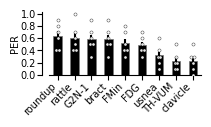

In [6]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


# ======================================
# 공통 레이아웃
# ======================================

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.32

BAR_H = 1.0

fontsize = 7
lp = 1

bar_spacing = 0.15
bar_width = 0.075


# ======================================
# 데이터 정리
# ======================================

cols = [
    'FMin SS48944',
    'G2N-1 SS47080',
    'TH-VUM SS46885',
    'bract SS31386',
    'clavicle SS48947',
    'FDG SS31345',
    'rattle SS46917',
    'roundup SS47745',
    'usnea SS15725'
]

mean_mat = pd.DataFrame(
    index=cols,
    columns=['- geosmin', '+ geosmin']
)

std_mat = pd.DataFrame(
    index=cols,
    columns=['- geosmin', '+ geosmin']
)

for condition, df in data_df_optogenetics.items():
    mean_mat[condition] = df.mean(axis=0)
    std_mat[condition] = std_err(df)

mean_mat = mean_mat.sort_values(
    by='- geosmin',
    ascending=False
)

std_mat = std_mat.loc[mean_mat.index]


# ======================================
# Figure
# ======================================

fig, ax = plt.subplots(
    1, 1,
    figsize=(2, BAR_H),
    constrained_layout=False
)


# ======================================
# BAR + raw points
# ======================================

conditions = mean_mat.index.tolist()
groups = ['- geosmin']

xloc = draw_bar_with_points(
    ax=ax,
    conditions=conditions,
    groups=groups,

    get_values=lambda cond, group:
        data_df_optogenetics[group][cond],

    get_mean=lambda cond, group:
        mean_mat.loc[cond, group],

    get_err=lambda cond, group:
        std_mat.loc[cond, group],

    bar_width=bar_width,
    bar_spacing=bar_spacing,

    colors=['#000000'],

    edgecolor='#777777',
    linewidth=0.5,
    capsize=0,

    point_facecolor='white',
    point_edgecolor='black',
    point_lw=0.3,
    point_size=5,
    point_alpha=0.9
)


# ======================================
# Axis formatting
# ======================================

xlabel = [
    x.split(" ")[0]
    for x in conditions
]

ax.set_xticks(
    xloc,
    xlabel,
    rotation=45,
    ha='right'
)

ax.set_yticks(
    np.arange(0, 1.1, .2)
)

ax.set_ylabel(
    'PER',
    labelpad=lp
)

ax.set_ylim([0, 1.03])

ax.set_xlim(
    -bar_spacing / 2,
    xloc[-1] + bar_spacing / 2
)

ax.spines[['top', 'right']].set_visible(False)

ax.spines['left'].set_position(
    ('outward', 5)
)

ax.tick_params(pad=1)

ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5

if ax.get_legend() is not None:
    ax.get_legend().remove()


# ======================================
# Layout
# ======================================

fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)


# ======================================
# Save
# ======================================

# plt.savefig(
#     'figures/optogenetic_activation_add_version_with_equal_amp_wo_phantom.svg'
# )